In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from vectorization.vectorizer_selector import VectorizerSelector


In [2]:
df = pd.read_pickle("../results/preprocessed.pkl")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 3)


,review,sentiment,cleaned
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,"[basically, family, little, boy, jake, think, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, mattei, love, time, money, visually, ..."


In [3]:
import sys
import os
import scipy.sparse

sys.path.append(os.path.abspath(".."))

from vectorization.bow import BoWVectorizer
from vectorization.tfidf import TfidfVectorizerWrapper

os.makedirs("../results", exist_ok=True)

bow_vectorizer = BoWVectorizer()
X_bow = bow_vectorizer.fit_transform(df)

tfidf_vectorizer = TfidfVectorizerWrapper()
X_tfidf = tfidf_vectorizer.fit_transform(df)

scipy.sparse.save_npz("../results/X_bow.npz", X_bow)
scipy.sparse.save_npz("../results/X_tfidf.npz", X_tfidf)

with open("../results/bow_vectorizer.pkl", "wb") as f:
    pickle.dump(bow_vectorizer, f)

with open("../results/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("Matrices saved as .npz (sparse format)")
print("Vectorizers saved as .pkl (pickle format)")

Matrices saved as .npz (sparse format)
Vectorizers saved as .pkl (pickle format)


In [4]:
print("BoW matrix shape:", X_bow.shape)
print("TF-IDF matrix shape:", X_tfidf.shape)

BoW matrix shape: (50000, 89220)
TF-IDF matrix shape: (50000, 89220)


In [5]:
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
words = bow_vectorizer.vectorizer.get_feature_names_out()

count_df = pd.DataFrame({'word': words, 'count': word_counts})
count_df = count_df.sort_values(by='count', ascending=False)
bow_top_20 = count_df.head(20)
bow_top_20

,word,count
52273,movie,99813
28061,film,90383
55800,one,53019
45556,like,39975
79375,time,29643
32396,good,28794
12883,character,27736
87725,would,26454
25921,even,24517
31418,get,24449


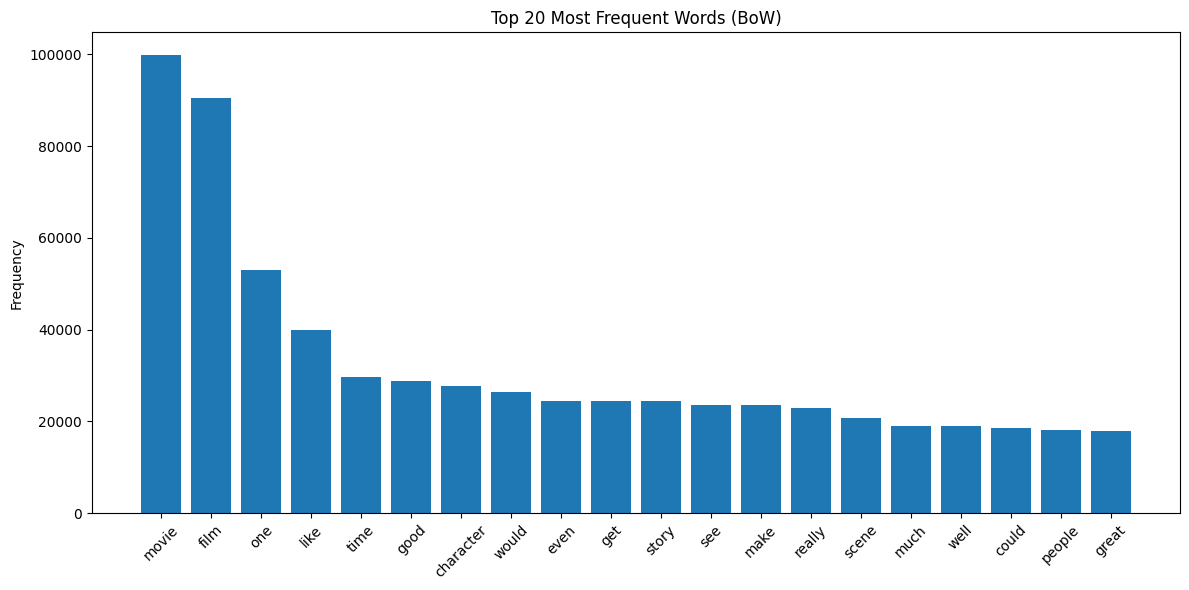

In [6]:
plt.figure(figsize=(12, 6))
plt.bar(bow_top_20['word'], bow_top_20['count'])
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (BoW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
word_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()
words = tfidf_vectorizer.vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'tfidf_score': word_scores})
freq_df = freq_df.sort_values(by='tfidf_score', ascending=False)
top_tfidf = freq_df.head(20)
top_tfidf

,word,tfidf_score
52273,movie,0.053216
28061,film,0.043903
55800,one,0.026393
45556,like,0.022685
32396,good,0.019865
79375,time,0.018690
12883,character,0.017944
87725,would,0.017574
75105,story,0.017328
63828,really,0.017178


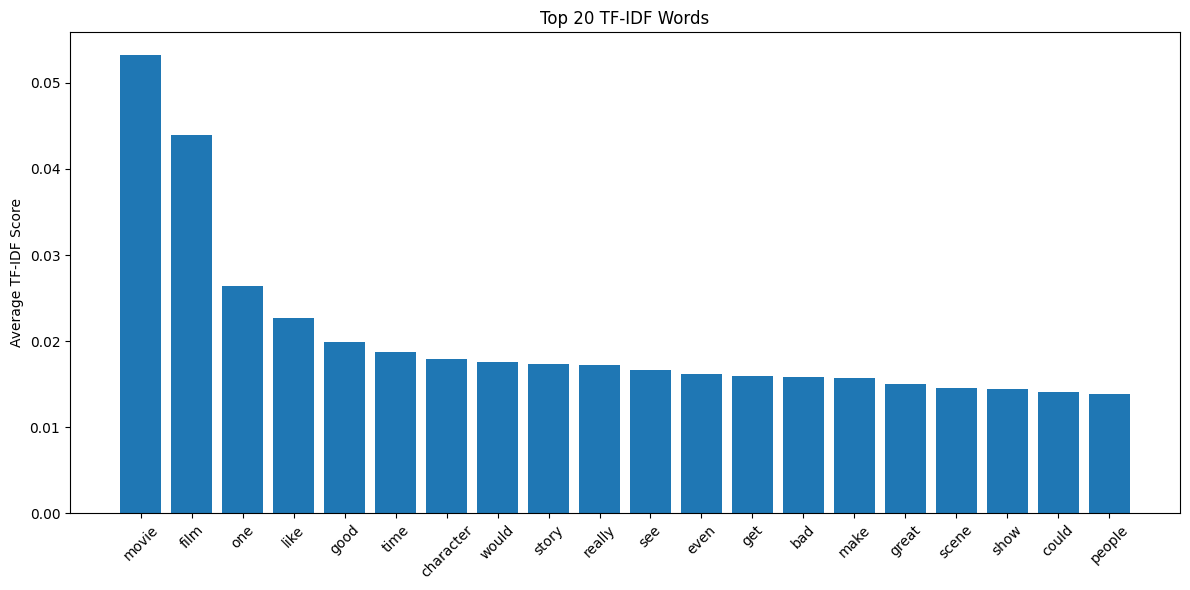

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(top_tfidf['word'], top_tfidf['tfidf_score'])
plt.xticks(rotation=45)
plt.title("Top 20 TF-IDF Words")
plt.ylabel("Average TF-IDF Score")
plt.tight_layout()
plt.show()

In [9]:
selected_words = bow_top_20.head(10)['word'].tolist()
selected_word_indices = [
    bow_vectorizer.vectorizer.vocabulary_[word]
    for word in selected_words
]


bow_subset = pd.DataFrame(
    X_bow[:5, selected_word_indices].toarray(),
    columns=selected_words
)
bow_subset.index = [f"Review {i}" for i in range(1, 6)]
bow_subset

,movie,film,one,like,time,good,character,would,even,get
Review 1,0,0,1,0,0,0,0,2,0,2
Review 2,0,0,1,0,0,0,0,0,0,0
Review 3,0,0,1,0,1,0,1,0,1,0
Review 4,3,2,0,1,0,0,0,0,0,0
Review 5,1,2,6,0,2,2,2,0,0,1


In [10]:
tfidf_subset = pd.DataFrame(
    X_tfidf[:5, selected_word_indices].toarray(),
    columns=selected_words
)
tfidf_subset.index = [f"Review {i}" for i in range(1, 6)]
tfidf_subset

,movie,film,one,like,time,good,character,would,even,get
Review 1,0.000000,0.000000,0.018644,0.000000,0.000000,0.000000,0.000000,0.049242,0.000000,0.050309
Review 2,0.000000,0.000000,0.029673,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Review 3,0.000000,0.000000,0.032904,0.000000,0.040648,0.000000,0.044394,0.000000,0.044065,0.000000
Review 4,0.089463,0.063977,0.000000,0.036553,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Review 5,0.021789,0.046746,0.142191,0.000000,0.058553,0.059928,0.063948,0.000000,0.000000,0.031973


In [19]:
# Broj dokumenata u kojima se svaka rec pojavljuje (= min_df logika)
doc_freq = np.asarray((X_bow > 0).sum(axis=0)).flatten()
words = bow_vectorizer.vectorizer.get_feature_names_out()

doc_freq_df = pd.DataFrame({'word': words, 'doc_count': doc_freq.astype(int)})

print(f"Total unique words: {len(doc_freq_df)}")
print(f"\nWords in only 1 document:  {(doc_freq_df['doc_count'] == 1).sum()}")
print(f"Words in only 2 documents: {(doc_freq_df['doc_count'] == 2).sum()}")
print(f"Words in only 3 documents: {(doc_freq_df['doc_count'] == 3).sum()}")
print(f"Words in only 4 documents: {(doc_freq_df['doc_count'] == 4).sum()}")
print(f"Words in ≤5 documents:     {(doc_freq_df['doc_count'] <= 5).sum()}")

Total unique words: 89220

Words in only 1 document:  38276
Words in only 2 documents: 10220
Words in only 3 documents: 5472
Words in only 4 documents: 3782
Words in ≤5 documents:     60425


In [20]:
print("Examples of words in only 1 document:")
rare = doc_freq_df[doc_freq_df['doc_count'] == 1].sample(20, random_state=42)
print(rare['word'].tolist())

print("\nExamples of words in only 2 documents:")
rare2 = doc_freq_df[doc_freq_df['doc_count'] == 2].sample(20, random_state=42)
print(rare2['word'].tolist())

Examples of words in only 1 document:
['gogeta', 'strapless', 'elivates', 'jigoku', 'krags', 'speculates', 'obscurantist', 'cheekily', 'ackward', 'heffernans', 'deterrance', 'offto', 'syncronization', 'penislized', 'auie', 'londonesque', 'wisselwachter', 'hudsom', 'shiranui', 'notgr']

Examples of words in only 2 documents:
['tabor', 'klavan', 'baller', 'abscond', 'tediousness', 'cytown', 'madiba', 'fabiani', 'gorbunov', 'ani', 'horribble', 'hebetude', 'midas', 'sizzled', 'feeblest', 'lemay', 'casualness', 'malvolio', 'finiteness', 'cometh']


min_df=1: vocabulary size = 89,220
min_df=2: vocabulary size = 50,944
min_df=3: vocabulary size = 40,724
min_df=5: vocabulary size = 31,470
min_df=10: vocabulary size = 22,247


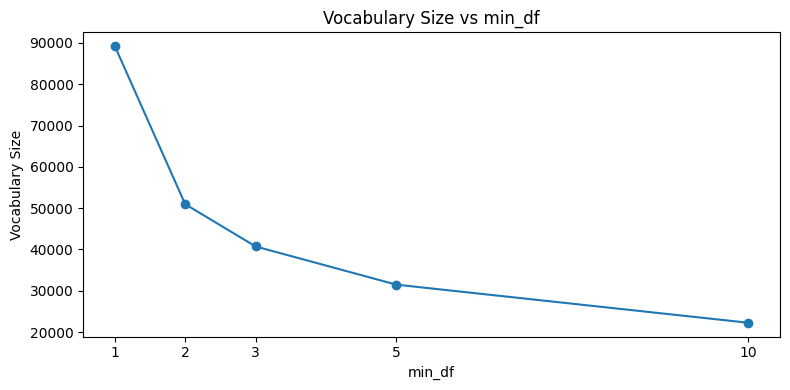

In [21]:
min_dfs = [1, 2, 3, 5, 10]
vocab_sizes = []

for min_df in min_dfs:
    selector = VectorizerSelector(method='bow', min_df=min_df)
    bow = selector.get_vectorizer()
    X = bow.fit_transform(df)
    vocab_sizes.append(X.shape[1])
    print(f"min_df={min_df}: vocabulary size = {X.shape[1]:,}")

plt.figure(figsize=(8, 4))
plt.plot(min_dfs, vocab_sizes, marker='o')
plt.title('Vocabulary Size vs min_df')
plt.xlabel('min_df')
plt.ylabel('Vocabulary Size')
plt.xticks(min_dfs)
plt.tight_layout()
plt.show()